# Model 1A, Random Forest Experiment 02: Rotation and Dual-Scope W60 Backlog

This controlled experiment gives Random Forest the exact 41 source fields selected by CatBoost Experiment 04: the 20-field raw pre-pushback base, all 13 full-history rotation fields with the 24-hour long-turn mask, three compact airport-wide W60 backlog fields, and five same-airline W60 fields. It uses five expanding chronological folds within 2019, selects hyperparameters and an operating threshold from 2019 only, and evaluates once on 2023. The 2024 final-test year is never loaded.

The purpose is not merely to add another classifier. It separates the value of the engineered feature family from CatBoost's boosting and native categorical treatment. The established feature files are paired in memory after exact identity validation; no combined dataset is written. The final-tail assignment caveat makes this a retrospective upper-bound experiment.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    balanced_accuracy_score, brier_score_loss, f1_score,
    matthews_corrcoef, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"
BACKLOG_WINDOW_MINUTES = 60
LONG_TURN_HOURS = 24
RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"scikit-learn {sklearn.__version__}")

scikit-learn 1.9.0


## Pair and validate the three established feature paths

In [2]:
def find_project_root(start: Path) -> Path:
    required = [
        Path("data/features") / f"{AIRPORT}_{year}_departures_{kind}.csv"
        for year in (TRAIN_YEAR, VALIDATION_YEAR)
        for kind in (
            "rotation_full_history",
            f"backlog_w{BACKLOG_WINDOW_MINUTES}",
            f"backlog_airline_w{BACKLOG_WINDOW_MINUTES}",
        )
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required experiment files: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
rotation_frames, backlog_frames, airline_backlog_frames = {}, {}, {}
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    feature_dir = PROJECT_ROOT / "data/features"
    rotation_path = feature_dir / f"{AIRPORT}_{year}_departures_rotation_full_history.csv"
    backlog_path = feature_dir / f"{AIRPORT}_{year}_departures_backlog_w{BACKLOG_WINDOW_MINUTES}.csv"
    airline_path = feature_dir / f"{AIRPORT}_{year}_departures_backlog_airline_w{BACKLOG_WINDOW_MINUTES}.csv"
    rotation_frames[partition] = pd.read_csv(rotation_path, low_memory=False)
    backlog_frames[partition] = pd.read_csv(backlog_path, low_memory=False)
    airline_backlog_frames[partition] = pd.read_csv(airline_path, low_memory=False)
    print(f"{partition:10s}: {len(rotation_frames[partition]):,} rotation rows <- {rotation_path.name}")
    print(f"{'':10s}  {len(backlog_frames[partition]):,} airport backlog rows <- {backlog_path.name}")
    print(f"{'':10s}  {len(airline_backlog_frames[partition]):,} airline backlog rows <- {airline_path.name}")


training  : 107,430 rotation rows <- JFK_2019_departures_rotation_full_history.csv
            107,430 airport backlog rows <- JFK_2019_departures_backlog_w60.csv
            107,430 airline backlog rows <- JFK_2019_departures_backlog_airline_w60.csv


validation: 109,983 rotation rows <- JFK_2023_departures_rotation_full_history.csv
            109,983 airport backlog rows <- JFK_2023_departures_backlog_w60.csv
            109,983 airline backlog rows <- JFK_2023_departures_backlog_airline_w60.csv


In [3]:
ROTATION_FEATURES = [
    "ROTATION_STATUS", "ROTATION_MATCH_FOUND", "ROTATION_INBOUND_ORIGIN",
    "ROTATION_SCHEDULED_TURN_MINUTES",
    "ROTATION_INBOUND_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_OVERDUE_MINUTES",
    "ROTATION_LOG_INBOUND_OVERDUE_MINUTES",
    "ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_LOG_ACTUAL_TURN_MINUTES",
    "ROTATION_INBOUND_ARR_DELAY", "ROTATION_INBOUND_DELAYED_15",
    "ROTATION_LOG_SCHEDULED_TURN_MINUTES",
]
ROTATION_AUDIT_COLUMNS = [
    "ROTATION_TARGET_CUTOFF_UTC", "ROTATION_PRIOR_REPORTING_AIRLINE",
    "ROTATION_PRIOR_FLIGHT_NUMBER", "ROTATION_PRIOR_FLIGHT_DATE",
    "ROTATION_PRIOR_SCHEDULED_DEPARTURE_UTC",
    "ROTATION_PRIOR_SCHEDULED_ARRIVAL_UTC",
    "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC",
    "ROTATION_SCHEDULE_RECONSTRUCTION_ERROR_MINUTES",
]
BACKLOG_PREFIX = f"BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_SCHEDULED_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{BACKLOG_PREFIX}_DELAY_RATE", f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
]
COMPACT_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
]
AIRLINE_BACKLOG_PREFIX = f"AIRLINE_BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_AIRLINE_BACKLOG_FEATURES = [
    f"{AIRLINE_BACKLOG_PREFIX}_SCHEDULED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAY_RATE",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{AIRLINE_BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_SHARE",
]
SELECTED_AIRLINE_BACKLOG_FEATURES = [
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAY_RATE",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_SHARE",
]
IDENTITY_COLUMNS = [
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "Dest", "CRSDepTime", "Tail_Number", TARGET,
]

combined_frames, source_rows = {}, []
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    rotation = rotation_frames[partition]
    backlog = backlog_frames[partition]
    airline_backlog = airline_backlog_frames[partition]
    required_rotation = {"FlightDate", "DATE", "Origin", TARGET, *ROTATION_FEATURES, *ROTATION_AUDIT_COLUMNS}
    required_backlog = {"FlightDate", "DATE", "Origin", TARGET, *FULL_BACKLOG_FEATURES}
    required_airline = {"FlightDate", "DATE", "Origin", TARGET, *FULL_AIRLINE_BACKLOG_FEATURES}
    assert not required_rotation.difference(rotation.columns)
    assert not required_backlog.difference(backlog.columns)
    assert not required_airline.difference(airline_backlog.columns)
    assert len(rotation) == len(backlog) == len(airline_backlog)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], backlog[IDENTITY_COLUMNS], check_dtype=False)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], airline_backlog[IDENTITY_COLUMNS], check_dtype=False)
    rotation["FlightDate"] = pd.to_datetime(rotation["FlightDate"], errors="raise")
    backlog["FlightDate"] = pd.to_datetime(backlog["FlightDate"], errors="raise")
    airline_backlog["FlightDate"] = pd.to_datetime(airline_backlog["FlightDate"], errors="raise")
    cutoff = pd.to_datetime(backlog["DATE"], errors="raise")
    airline_cutoff = pd.to_datetime(airline_backlog["DATE"], errors="raise")
    pd.testing.assert_series_equal(cutoff, airline_cutoff, check_names=False)
    assert rotation["FlightDate"].dt.year.eq(year).all() and rotation["Origin"].eq(AIRPORT).all()

    match = pd.to_numeric(rotation["ROTATION_MATCH_FOUND"], errors="raise")
    arrived = pd.to_numeric(rotation["ROTATION_INBOUND_ARRIVED_BY_CUTOFF"], errors="raise")
    not_arrived = pd.to_numeric(rotation["ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"], errors="raise")
    assert match.eq(arrived + not_arrived).all()
    actual_only = ["ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_INBOUND_ARR_DELAY",
                   "ROTATION_INBOUND_DELAYED_15", "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC"]
    assert not rotation.loc[arrived.eq(0), actual_only].notna().any().any()

    scheduled, completed, pending, delayed_count = (
        pd.to_numeric(backlog[column], errors="raise") for column in FULL_BACKLOG_FEATURES[:4]
    )
    assert scheduled.eq(completed + pending).all() and delayed_count.le(completed).all()
    same_cutoff_variants = (backlog.assign(_CUTOFF=cutoff)
        .groupby("_CUTOFF", sort=False)[FULL_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_cutoff_variants <= 1

    airline_scheduled, airline_completed, airline_pending, airline_delayed = (
        pd.to_numeric(airline_backlog[column], errors="raise")
        for column in FULL_AIRLINE_BACKLOG_FEATURES[:4]
    )
    airline_share = pd.to_numeric(airline_backlog[FULL_AIRLINE_BACKLOG_FEATURES[-1]], errors="coerce")
    assert airline_scheduled.eq(airline_completed + airline_pending).all()
    assert airline_delayed.le(airline_completed).all()
    has_airline_history = airline_scheduled.gt(0)
    assert airline_share.loc[~has_airline_history].isna().all()
    assert np.allclose(
        airline_share.loc[has_airline_history],
        airline_pending.loc[has_airline_history] / airline_scheduled.loc[has_airline_history],
    )
    normalized_airline = airline_backlog["Reporting_Airline"].astype("string").str.strip().str.upper()
    same_airline_cutoff_variants = (airline_backlog.assign(_CUTOFF=airline_cutoff, _AIRLINE=normalized_airline)
        .groupby(["_AIRLINE", "_CUTOFF"], sort=False)[FULL_AIRLINE_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_airline_cutoff_variants <= 1

    combined = rotation.copy()
    for column in COMPACT_BACKLOG_FEATURES:
        combined[column] = backlog[column].to_numpy()
    for column in FULL_AIRLINE_BACKLOG_FEATURES:
        combined[column] = airline_backlog[column].to_numpy()
    combined_frames[partition] = combined
    source_rows.append({
        "partition": partition, "year": year, "rows": len(combined),
        "delay_rate": combined[TARGET].mean(), "rotation_match_rate": match.mean(),
        "not_arrived_rows": int(not_arrived.sum()), "mean_airport_pending": pending.mean(),
        "mean_airline_pending": airline_pending.mean(),
        "airline_pending_rows": int(airline_pending.gt(0).sum()),
        "airport_cutoff_violations": int(same_cutoff_variants > 1),
        "airline_cutoff_violations": int(same_airline_cutoff_variants > 1),
    })
source_summary = pd.DataFrame(source_rows).set_index("partition")
source_summary


,year,rows,delay_rate,rotation_match_rate,not_arrived_rows,mean_airport_pending,mean_airline_pending,airline_pending_rows,airport_cutoff_violations,airline_cutoff_violations
partition,,,,,,,,,,
training,2019,107430,0.1877,0.9665,3133,2.4552,0.5685,36464,0,0
validation,2023,109983,0.2364,0.9554,3565,3.0245,0.7171,43531,0,0


## Apply the 24-hour rotation mask and select CatBoost 04's exact manifest

In [4]:
def mask_long_turns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    long_turn = pd.to_numeric(result["ROTATION_SCHEDULED_TURN_MINUTES"], errors="coerce").gt(LONG_TURN_HOURS * 60)
    result.loc[long_turn, ROTATION_FEATURES] = np.nan
    result.loc[long_turn, "ROTATION_STATUS"] = "LONG_TURN_EXCLUDED"
    return result


model_frames = {partition: mask_long_turns(frame) for partition, frame in combined_frames.items()}
BASE_CATEGORICAL_FEATURES = ["Month", "DayOfWeek", "Reporting_Airline", "Dest"]
BASE_NUMERIC_FEATURES = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES", "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES", "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES", "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature", "HourlyDryBulbTemperature",
    "HourlyPrecipitation", "HourlyRelativeHumidity",
    "HourlyVisibility", "HourlyWindSpeed",
]
ROTATION_CATEGORICAL = ["ROTATION_STATUS", "ROTATION_INBOUND_ORIGIN"]
ROTATION_NUMERIC = [column for column in ROTATION_FEATURES if column not in ROTATION_CATEGORICAL]
categorical_features = [*BASE_CATEGORICAL_FEATURES, *ROTATION_CATEGORICAL]
shared_numeric_features = [*BASE_NUMERIC_FEATURES, *ROTATION_NUMERIC, *COMPACT_BACKLOG_FEATURES]
variant_features = {
    "CatBoost 02 control": [*categorical_features, *shared_numeric_features],
    "plus same-airline W60": [
        *categorical_features, *shared_numeric_features, *SELECTED_AIRLINE_BACKLOG_FEATURES
    ],
}
all_numeric_features = [*shared_numeric_features, *SELECTED_AIRLINE_BACKLOG_FEATURES]
required_columns = list(dict.fromkeys([
    "FlightDate", "CRSDepTime", TARGET, *categorical_features, *all_numeric_features
]))
assert len(categorical_features) == 6 and len(shared_numeric_features) == 30
assert len(variant_features["CatBoost 02 control"]) == 36
assert len(variant_features["plus same-airline W60"]) == 41
for partition, frame in model_frames.items():
    assert not set(required_columns).difference(frame.columns), partition
forbidden = {
    TARGET, "DepTime", "DepDelay", "DepDelayMinutes", "TaxiOut",
    "WheelsOff", "WheelsOn", "TaxiIn", "ArrTime", "ArrDelay",
    "ArrDelayMinutes", "ArrDel15", "ActualElapsedTime", "AirTime",
    "Tail_Number", *ROTATION_AUDIT_COLUMNS,
}
assert not forbidden.intersection(set().union(*map(set, variant_features.values())))
pd.DataFrame({
    name: {"source fields": len(columns), "categorical": len(categorical_features),
           "numeric": len(columns) - len(categorical_features),
           "airport backlog fields": len([c for c in columns if c.startswith(BACKLOG_PREFIX)]),
           "airline backlog fields": len([c for c in columns if c.startswith(AIRLINE_BACKLOG_PREFIX)])}
    for name, columns in variant_features.items()
}).T


SELECTED_MANIFEST = "plus same-airline W60"
feature_columns = variant_features[SELECTED_MANIFEST]
numeric_features = [column for column in feature_columns if column not in categorical_features]
assert len(feature_columns) == 41
assert len(categorical_features) == 6 and len(numeric_features) == 35
print(f"Selected manifest: {SELECTED_MANIFEST}")
print(f"Source fields: {len(feature_columns)} ({len(categorical_features)} categorical, {len(numeric_features)} numeric)")

Selected manifest: plus same-airline W60
Source fields: 41 (6 categorical, 35 numeric)


In [5]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    for column in categorical_features:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in all_numeric_features:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


train_model_df = prepare_model_frame(model_frames["training"])
validation_model_df = prepare_model_frame(model_frames["validation"])
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)
X_train_variants = {
    name: train_model_df[columns].reset_index(drop=True)
    for name, columns in variant_features.items()
}
X_validation_variants = {
    name: validation_model_df[columns].reset_index(drop=True)
    for name, columns in variant_features.items()
}
assert training_dates.max() < validation_dates.min()
missing_summary = pd.DataFrame({
    "training_missing": train_model_df[all_numeric_features].isna().sum(),
    "validation_missing": validation_model_df[all_numeric_features].isna().sum(),
})
missing_summary[missing_summary.sum(axis=1).gt(0)]


X_train = X_train_variants[SELECTED_MANIFEST]
X_validation = X_validation_variants[SELECTED_MANIFEST]
assert X_train.shape == (len(y_train), 41)
assert X_validation.shape == (len(y_validation), 41)

In [6]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    day_blocks = np.array_split(np.array(sorted(pd.unique(normalized))), n_splits + 1)
    splits, rows = [], []
    for fold in range(1, n_splits + 1):
        train_days, heldout_days = np.concatenate(day_blocks[:fold]), day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold, "train_rows": len(train_idx), "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(training_dates, y_train, N_TIME_SPLITS)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17737,18776,2019-03-02,2019-03-03,2019-05-02,0.1892,0.1674
2,36513,18150,2019-05-02,2019-05-03,2019-07-02,0.1780,0.2072
3,54663,17758,2019-07-02,2019-07-03,2019-09-01,0.1877,0.2577
4,72421,17686,2019-09-01,2019-09-02,2019-11-01,0.2048,0.1384
5,90107,17323,2019-11-01,2019-11-02,2019-12-31,0.1918,0.1666


## Fold-local preprocessing and controlled Random Forest search

In [7]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
])
preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features),
], remainder="drop")

forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300, criterion="gini", bootstrap=True, oob_score=True,
        n_jobs=N_JOBS, random_state=RANDOM_STATE,
    )),
])

# A deliberately bounded search: feature sampling, regularization, and imbalance handling
# vary while tree count remains fixed at a stable ensemble size.
parameter_grid = {
    "classifier__max_depth": [12, 18],
    "classifier__min_samples_leaf": [25, 100],
    "classifier__max_features": ["sqrt", 0.5],
    "classifier__class_weight": [None, "balanced_subsample"],
}
scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "neg_brier": "neg_brier_score",
}
grid_search = GridSearchCV(
    forest_pipeline, parameter_grid, scoring=scoring, refit="average_precision",
    cv=temporal_splits, n_jobs=1, verbose=1, return_train_score=False,
    error_score="raise",
)
candidate_count = len(list(ParameterGrid(parameter_grid)))
print(f"Hyperparameter combinations: {candidate_count}")
print(f"Temporal search fits: {candidate_count * N_TIME_SPLITS}")

Hyperparameter combinations: 16
Temporal search fits: 80


In [8]:
search_start = perf_counter()
grid_search.fit(X_train, y_train)
search_seconds = perf_counter() - search_start
best_pipeline = grid_search.best_estimator_
fitted_forest = best_pipeline.named_steps["classifier"]
print(f"Search and all-2019 refit completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal AP: {grid_search.best_score_:.4f}")
print(f"OOB accuracy diagnostic: {fitted_forest.oob_score_:.4f}")
display(pd.Series(grid_search.best_params_, name="value").to_frame())

cv_results = pd.DataFrame(grid_search.cv_results_)
result_columns = [
    "rank_test_average_precision", "mean_test_average_precision",
    "std_test_average_precision", "mean_test_roc_auc", "mean_test_neg_brier",
    "param_classifier__max_depth", "param_classifier__min_samples_leaf",
    "param_classifier__max_features", "param_classifier__class_weight",
]
display(cv_results.sort_values("rank_test_average_precision")[result_columns].head(12))

Fitting 5 folds for each of 16 candidates, totalling 80 fits


Search and all-2019 refit completed in 1,251.2 seconds
Best mean temporal AP: 0.6996
OOB accuracy diagnostic: 0.8840


,value
classifier__class_weight,NaN
classifier__max_depth,18.0000
classifier__max_features,0.5000
classifier__min_samples_leaf,25.0000


,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_neg_brier,param_classifier__max_depth,param_classifier__min_samples_leaf,param_classifier__max_features,param_classifier__class_weight
6,1,0.6996,0.0537,0.8426,-0.0920,18,25,0.5000,NaN
2,2,0.6977,0.0544,0.8406,-0.0923,12,25,0.5000,NaN
14,3,0.6976,0.0541,0.8424,-0.1191,18,25,0.5000,balanced_subsample
10,4,0.6970,0.0543,0.8415,-0.1253,12,25,0.5000,balanced_subsample
4,5,0.6930,0.0543,0.8424,-0.0950,18,25,sqrt,NaN
7,6,0.6920,0.0542,0.8408,-0.0939,18,100,0.5000,NaN
12,7,0.6914,0.0552,0.8428,-0.1318,18,25,sqrt,balanced_subsample
3,8,0.6908,0.0545,0.8390,-0.0940,12,100,0.5000,NaN
15,9,0.6901,0.0542,0.8402,-0.1333,18,100,0.5000,balanced_subsample
11,10,0.6897,0.0543,0.8395,-0.1345,12,100,0.5000,balanced_subsample


## Generate selected-model held-out probabilities and choose the threshold using 2019 only

In [9]:
oof_probabilities = np.full(len(y_train), np.nan)
fold_rows = []
for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
    fold_model = clone(best_pipeline)
    fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    probabilities = fold_model.predict_proba(X_train.iloc[heldout_idx])[:, 1]
    oof_probabilities[heldout_idx] = probabilities
    fold_rows.append({
        "fold": fold_number,
        "average_precision": average_precision_score(y_train.iloc[heldout_idx], probabilities),
        "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
        "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
    })
    print(f"Completed selected Random Forest fold {fold_number}/{N_TIME_SPLITS}")

fold_results = pd.DataFrame(fold_rows).set_index("fold")
oof_mask = np.isfinite(oof_probabilities)
oof_y, oof_p = y_train.to_numpy()[oof_mask], oof_probabilities[oof_mask]
threshold_rows = []
for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2):
    predictions = (oof_p >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "balanced_accuracy": balanced_accuracy_score(oof_y, predictions),
        "precision": precision_score(oof_y, predictions, zero_division=0),
        "recall": recall_score(oof_y, predictions, zero_division=0),
        "f1": f1_score(oof_y, predictions, zero_division=0),
        "mcc": matthews_corrcoef(oof_y, predictions),
    })
threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"], ascending=False
).iloc[0]
selected_threshold = float(best_threshold_row["threshold"])
print(f"Mean temporal AP: {fold_results['average_precision'].mean():.4f}")
print(f"Aggregated OOF AP: {average_precision_score(oof_y, oof_p):.4f}")
print(f"Training-selected threshold: {selected_threshold:.2f}")
display(fold_results)
threshold_results.sort_values(["f1", "balanced_accuracy"], ascending=False).head(10)

Completed selected Random Forest fold 1/5


Completed selected Random Forest fold 2/5


Completed selected Random Forest fold 3/5


Completed selected Random Forest fold 4/5


Completed selected Random Forest fold 5/5


Mean temporal AP: 0.6996
Aggregated OOF AP: 0.7127
Training-selected threshold: 0.31


,average_precision,roc_auc,brier_score
fold,,,
1,0.6654,0.8318,0.0896
2,0.7358,0.8486,0.0970
3,0.7865,0.8678,0.1086
4,0.6402,0.8277,0.0766
5,0.6703,0.8371,0.0883


,threshold,balanced_accuracy,precision,recall,f1,mcc
26,0.3100,0.7591,0.6869,0.5791,0.6284,0.5544
27,0.3200,0.7565,0.6996,0.5695,0.6279,0.5569
28,0.3300,0.7544,0.7128,0.5610,0.6279,0.5600
25,0.3000,0.7606,0.6730,0.5869,0.6270,0.5500
24,0.2900,0.7628,0.6595,0.5967,0.6265,0.5467
29,0.3400,0.7517,0.7245,0.5518,0.6265,0.5616
30,0.3500,0.7498,0.7348,0.5451,0.6259,0.5636
23,0.2800,0.7649,0.6461,0.6063,0.6256,0.5430
31,0.3600,0.7476,0.7454,0.5375,0.6246,0.5652
22,0.2700,0.7669,0.6325,0.6164,0.6244,0.5391


## Evaluate the fixed model once on 2023

In [10]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }

validation_probabilities = best_pipeline.predict_proba(X_validation)[:, 1]
evaluation_results = pd.DataFrame([
    {"policy": "Default", **evaluate_probabilities(y_validation, validation_probabilities, 0.50)},
    {"policy": "Training-selected F1", **evaluate_probabilities(
        y_validation, validation_probabilities, selected_threshold
    )},
]).set_index("policy")
evaluation_results

,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
policy,,,,,,,,,,
Default,0.5000,0.8528,0.7107,0.8733,0.4412,0.5863,0.5521,0.8477,0.7409,0.1111
Training-selected F1,0.3100,0.8452,0.7570,0.7069,0.5896,0.6429,0.5488,0.8477,0.7409,0.1111


## Inspect feature importance and publishable diagnostics

,value
source fields,41.0000
prepared fields,210.0000
trees,300.0000
mean tree depth,18.0000
mean leaves,951.6400
training CV AP,0.6996
selected threshold,0.3100
validation prevalence,0.2364
validation AP,0.7409
validation ROC AUC,0.8477


,source_feature,importance
27,ROTATION_ACTUAL_TURN_MINUTES,0.1297
34,ROTATION_LOG_ACTUAL_TURN_MINUTES,0.1263
39,ROTATION_STATUS,0.0989
31,ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,0.0712
35,ROTATION_LOG_INBOUND_OVERDUE_MINUTES,0.0593
33,ROTATION_INBOUND_OVERDUE_MINUTES,0.0566
29,ROTATION_INBOUND_ARR_DELAY,0.0512
13,BACKLOG_W60_PENDING_COUNT,0.0415
28,ROTATION_INBOUND_ARRIVED_BY_CUTOFF,0.0385
19,Distance,0.0280


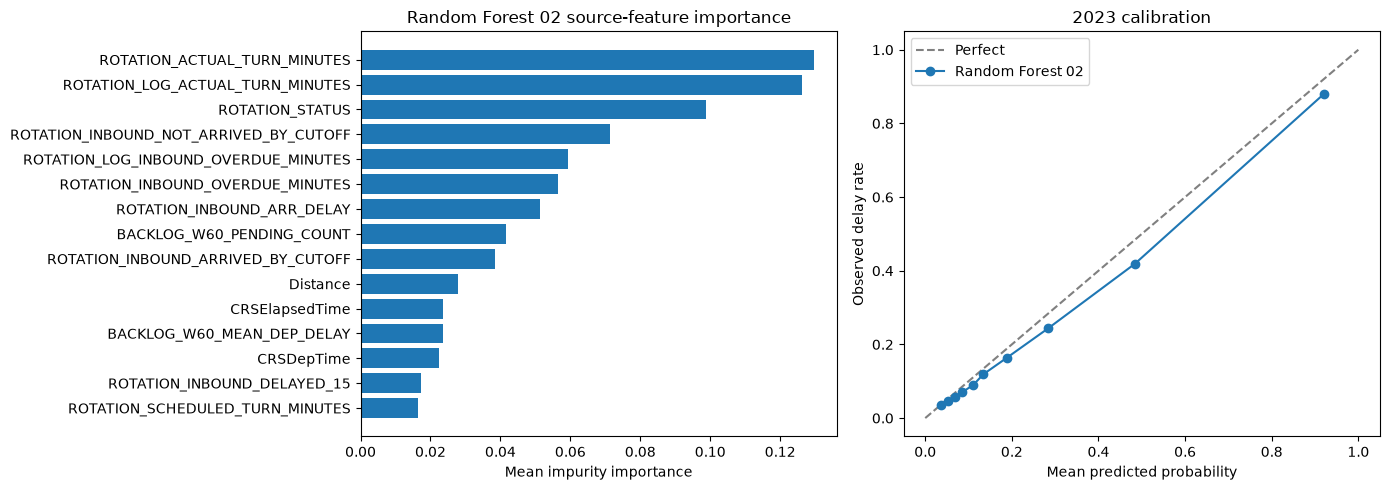

In [11]:
encoded_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

def source_feature(encoded_name):
    transformer, transformed = encoded_name.split("__", 1)
    if transformer == "numeric":
        return transformed.removeprefix("missingindicator_")
    for column in sorted(categorical_features, key=len, reverse=True):
        if transformed == column or transformed.startswith(f"{column}_"):
            return column
    return transformed

importance = pd.DataFrame({
    "encoded_feature": encoded_names,
    "importance": fitted_forest.feature_importances_,
})
importance["source_feature"] = importance["encoded_feature"].map(source_feature)
source_importance = (importance.groupby("source_feature", as_index=False)["importance"].sum()
                     .sort_values("importance", ascending=False))
tree_depths = np.array([tree.get_depth() for tree in fitted_forest.estimators_])
tree_leaves = np.array([tree.get_n_leaves() for tree in fitted_forest.estimators_])
publishable = pd.Series({
    "source fields": len(feature_columns),
    "prepared fields": len(encoded_names),
    "trees": len(fitted_forest.estimators_),
    "mean tree depth": tree_depths.mean(),
    "mean leaves": tree_leaves.mean(),
    "training CV AP": fold_results["average_precision"].mean(),
    "selected threshold": selected_threshold,
    "validation prevalence": y_validation.mean(),
    "validation AP": average_precision_score(y_validation, validation_probabilities),
    "validation ROC AUC": roc_auc_score(y_validation, validation_probabilities),
    "validation Brier": brier_score_loss(y_validation, validation_probabilities),
}, name="value")
display(publishable.to_frame())
display(source_importance.head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top = source_importance.head(15).sort_values("importance")
axes[0].barh(top["source_feature"], top["importance"])
axes[0].set(title="Random Forest 02 source-feature importance", xlabel="Mean impurity importance")
predicted, observed = calibration_curve(y_validation, validation_probabilities, n_bins=10, strategy="quantile")
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
axes[1].plot(predicted, observed, marker="o", label="Random Forest 02")
axes[1].set(title="2023 calibration", xlabel="Mean predicted probability", ylabel="Observed delay rate")
axes[1].legend()
fig.tight_layout()
plt.show()

## Interpretation checklist

- Compare this experiment with CatBoost 04 on the same 41 source fields; this isolates classifier family from feature availability.
- Treat impurity importance as a model-use diagnostic rather than a causal effect.
- Prefer average precision for model ranking and use Brier score and the reliability curve for probability quality.
- The final-tail assignment limitation remains, and the 2024 final-test year remains untouched.